In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# load data
import os
import sys
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
sys.path.append('../')
# from utils.data import *
from utils import data, metrics
server_path = '/home/carsen/dm11_cluster/fengtongd/Desktop/approxineuro'
# load 100 neuron recordings (for one mouse)

mouse_id = 10

# train gabor model

In [21]:
# load images
data_path = '../data'

# load neurons
fname = '%s_nat30k_%s.npz'%(data.db[mouse_id]['mname'], data.db[mouse_id]['datexp'])
spks, istim_train, istim_test, xpos, ypos, spks_rep_all = data.load_neurons(file_path = os.path.join(data_path, fname), mouse_id = mouse_id)
n_stim, n_max_neurons = spks.shape
print(len(spks_rep_all))

# split train and validation set
itrain, ival = data.split_train_val(istim_train, train_frac=0.9)
ineur = np.arange(0, n_max_neurons) #np.arange(0, n_neurons, 5)

# normalize spks
spks, spks_rep_all = data.normalize_spks(spks, spks_rep_all, itrain)
spks_val = torch.from_numpy(spks[ival][:,ineur]) 
spks_rep_all = [spks_rep_all[i][:,ineur] for i in range(len(spks_rep_all))]

# ineurons = np.arange(data.NNs_valid[mouse_id])
ineurons = np.arange(0, n_max_neurons, 5)
# np.random.seed(42)
# ineurons = np.random.choice(ineurons, 100, replace=False)

fev_test = metrics.fev(spks_rep_all)
isort_neurons = np.argsort(fev_test)[::-1]
ineur = isort_neurons[ineurons]

print(spks.shape, spks_val.shape, len(spks_rep_all), spks_rep_all[0].shape)

spks = spks[:,ineur]
spks_val = spks_val[:,ineur]
spks_rep_all = [spks_rep_all[i][:,ineur] for i in range(len(spks_rep_all))]
print(spks.shape, spks_val.shape, len(spks_rep_all), spks_rep_all[0].shape)


loading activities from ../data/FX41_nat30k_2025_02_14.npz
500

splitting training and validation set...
there is currently no randomness in this function now, please make sure the istim_train is in random order!
itrain:  (26550,)
ival:  (2950,)

normalizing neural data...
(29500, 5247) torch.Size([2950, 5247]) 500 (10, 5247)
(29500, 1050) torch.Size([2950, 1050]) 500 (10, 1050)


In [15]:
# if mouse_id == 5:
#     xrange_max = 176
# else:
#     xrange_max = 130 
xrange_max = 20
img_all = data.load_images(data_path, file=os.path.join(data_path, data.img_file_name[mouse_id]), xrange=[0, xrange_max], downsample=2)
nimg, Ly, Lx = img_all.shape
print('img: ', img_all.shape, img_all.min(), img_all.max())

# img_train = torch.from_numpy(img[istim_train][itrain]).to(device).unsqueeze(1)
# img_val = torch.from_numpy(img[istim_train][ival]).to(device).unsqueeze(1)
# img_test = torch.from_numpy(img[istim_test]).to(device).unsqueeze(1)

# input_Ly, input_Lx = img_test.shape[-2:]

# print('img_train: ', img_train.shape, img_val.shape, img_test.shape)
# print('img_val: ', img_val.shape)
# print('img_test: ', img_test.shape)

raw image shape:  (68032, 66, 264)
cropped image shape:  (68032, 33, 10)
image mean:  126.563034
image std:  59.274998
img:  (68032, 33, 10) -2.135184 2.1667984


In [16]:
n_stim = 100 # spks.shape[0]
n_neurons = -1

# generate random data
if n_stim > 0:
    istims = np.random.choice(spks.shape[0], n_stim, replace=False)
else:
    n_stim = spks.shape[0]
    istims = np.arange(n_stim)
if n_neurons > 0:
    ineurons = np.random.choice(spks.shape[1], n_neurons, replace=False)
    X_test = [spks_rep_all[i][:,ineurons] for i in range(len(spks_rep_all))]
else:
    n_neurons = spks.shape[1]
    ineurons = np.arange(n_neurons)
    X_test = spks_rep_all.copy()
# ineurons = np.random.choice(spks.shape[1], n_neurons, replace=False)
# ineurons = np.arange(n_neurons)
X = spks[istims][:,ineurons]
# X = spks.copy()
# Ly, Lx = 6, 13
# img = np.random.randn(Ly, Lx, n_stim)
# # normalize
# img = (img - img.mean()) / img.std()
img = img_all[istim_train][istims].transpose(1,2,0)
# img_mean = img.mean()
# img_std = img.std()
# img = (img - img.mean()) / img.std()
img_test = img_all[istim_test].transpose(1,2,0)
print(f'img: {img.shape}, X: {X.shape}')
Ly, Lx, _ = img.shape

# itrain = np.random.choice(n_stim, int(4*n_stim/5), replace=False)
# itest = np.setdiff1d(np.arange(n_stim), itrain)
# # itest = ival

# # convert itrain to binary
# itrain_binary = np.zeros(n_stim)
# itrain_binary[itrain] = 1
# itest_binary = np.zeros(n_stim)
# itest_binary[itest] = 1

# itrain = itrain_binary.astype(bool)
# itest = itest_binary.astype(bool)

img: (33, 10, 100), X: (100, 1050)


In [20]:
len(X_test), X_test[0].shape

(500, (10, 1050))

In [22]:
from utils import gabor
result_dict = gabor.fit_gabor_model(X, img, X_test, img_test)

sigma: (7,), f: (5,), theta: (8,), ph: (8,), ar: (3,)
number of gabors: 6720
sigma: torch.Size([7, 5, 8, 8, 3, 1, 1]), f: torch.Size([7, 5, 8, 8, 3, 1, 1]), theta: torch.Size([7, 5, 8, 8, 3, 1, 1]), ph: torch.Size([7, 5, 8, 8, 3, 1, 1]), ar: torch.Size([7, 5, 8, 8, 3, 1, 1])
ycents: torch.Size([32, 9]), xcents: torch.Size([32, 9])
y=0, x=5, vmax=0.149, time 0.1s
y=1, x=5, vmax=0.164, time 0.2s
y=2, x=5, vmax=0.175, time 0.3s
y=3, x=5, vmax=0.186, time 0.4s
y=4, x=5, vmax=0.194, time 0.5s
y=5, x=5, vmax=0.203, time 0.6s
y=6, x=5, vmax=0.212, time 0.8s
y=7, x=5, vmax=0.219, time 0.9s
y=8, x=5, vmax=0.224, time 1.0s
y=9, x=5, vmax=0.230, time 1.1s
y=10, x=5, vmax=0.235, time 1.2s
y=11, x=5, vmax=0.240, time 1.3s
y=12, x=5, vmax=0.243, time 1.4s
y=13, x=5, vmax=0.246, time 1.5s
y=14, x=5, vmax=0.250, time 1.6s
y=15, x=5, vmax=0.253, time 1.7s
y=16, x=5, vmax=0.256, time 1.8s
y=17, x=5, vmax=0.260, time 1.9s
y=18, x=5, vmax=0.264, time 2.0s
y=19, x=5, vmax=0.267, time 2.1s
y=20, x=5, vmax=0

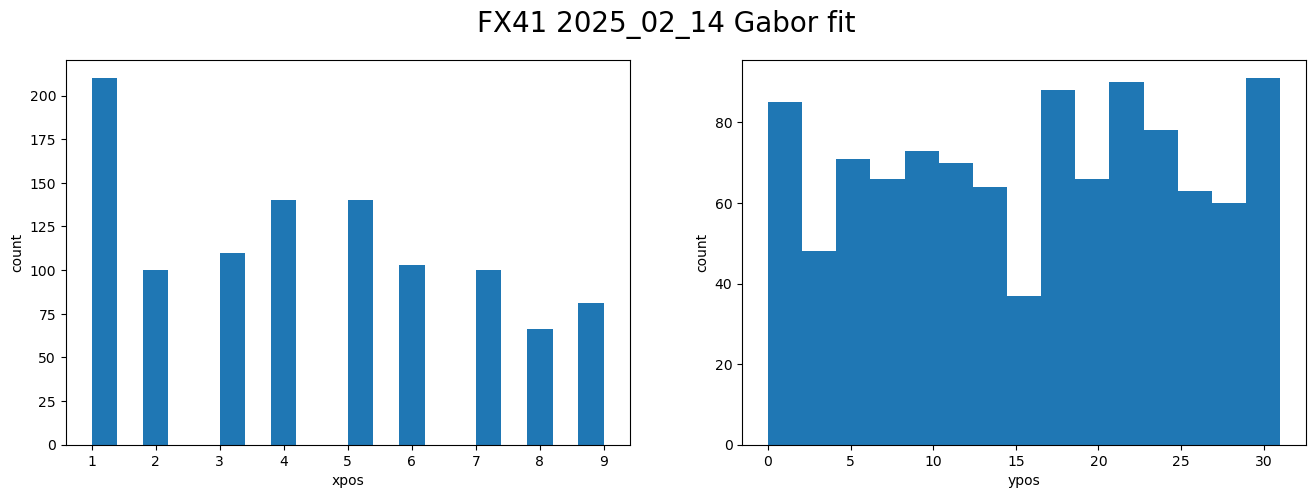

In [23]:
xmax, ymax = result_dict['xmax'], result_dict['ymax']

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
# distribution
ax[0].hist(xmax, bins=20)
ax[0].set_xlabel('xpos')
ax[0].set_ylabel('count')
ax[1].hist(ymax, bins=15)
ax[1].set_xlabel('ypos')
ax[1].set_ylabel('count')
plt.suptitle(f'{data.db[mouse_id]["mname"]} {data.db[mouse_id]["datexp"]} Gabor fit', fontsize=20)
plt.show()

dict_keys(['msigma', 'mf', 'mtheta', 'mph', 'mar', 'Amax', 'vmax', 'vmax_test', 'ymax', 'xmax', 'mu1', 'mu2', 'train_mu', 'train_std', 'fev', 'feve', 'rpred', 'gmax'])

In [ ]:
test_fev, test_feve = result_dict['fev'], result_dict['feve']
print('FEVE (test): ', np.mean(test_feve))

threshold = 0.01
print(f'filtering neurons with FEV > {threshold}')
valid_idxes = np.where(test_fev > threshold)[0]
print(f'valid neurons: {len(valid_idxes)} / {len(test_fev)}')
print(f'FEVE (test): {np.mean(test_feve[test_fev > threshold])}')

print(f'filtering neurons with FEV > {threshold} and FEVE > 0')
valid_idxes = np.where((test_fev > threshold) & (test_feve > 0))[0]
print(f'valid neurons: {len(valid_idxes)} / {len(test_fev)}')
print(f'FEVE (test): {np.mean(test_feve[valid_idxes])}')

FEVE (test):  0.7482446895332916
filtering neurons with FEV > 0.01
valid neurons: 337 / 1050
FEVE (test): -0.32722984465509153
filtering neurons with FEV > 0.01 and FEVE > 0
valid neurons: 26 / 1050
FEVE (test): 0.17785891457004122


In [ ]:
# save results
save_path = os.path.join('../weights', 'gabor', f'gabor_params_{data.db[mouse_id]["mname"]}_{data.db[mouse_id]["datexp"]}.npz')
np.savez(save_path, **result_dict)

# test

In [ ]:
# define gabor parameters
sigma = np.array([0.75, 1.25, 1.5, 2.5, 3.5, 4.5, 5.5])
f = np.array([0.1, 0.25, 0.5, 1, 2]) #[.01:.02:.13];
theta = np.arange(0, np.pi, np.pi/8)
ph = np.arange(0, 2*np.pi, np.pi/4)
ar = np.array([1, 1.5, 2])
print(f'sigma: {sigma.shape}, f: {f.shape}, theta: {theta.shape}, ph: {ph.shape}, ar: {ar.shape}')

params = np.meshgrid(sigma, f, theta, ph, ar, indexing='ij')
n_gabors = params[0].size
print(f'number of gabors: {n_gabors}')

for i in range(len(params)):
    params[i] = np.expand_dims(params[i], axis=(-2,-1))
    params[i] = torch.from_numpy(params[i].astype('float32'))
sigma, f, theta, ph, ar = params
print(f'sigma: {sigma.shape}, f: {f.shape}, theta: {theta.shape}, ph: {ph.shape}, ar: {ar.shape}')

sigma: (7,), f: (5,), theta: (8,), ph: (8,), ar: (3,)
number of gabors: 6720
sigma: torch.Size([7, 5, 8, 8, 3, 1, 1]), f: torch.Size([7, 5, 8, 8, 3, 1, 1]), theta: torch.Size([7, 5, 8, 8, 3, 1, 1]), ph: torch.Size([7, 5, 8, 8, 3, 1, 1]), ar: torch.Size([7, 5, 8, 8, 3, 1, 1])


In [ ]:
result_dict = np.load(save_path, allow_pickle=True)

In [ ]:
xmax, ymax = result_dict['xmax'], result_dict['ymax']
ys, xs = np.meshgrid(np.arange(0,Ly), np.arange(0,Lx), indexing='ij')
ys, xs = torch.from_numpy(ys.astype('float32')), torch.from_numpy(xs.astype('float32'))
gmax = result_dict['gmax']
gabor_params = torch.zeros((5, n_neurons, 1, 1))
for i in range(len(gabor_params)):
    gabor_params[i] = params[i].flatten()[gmax].reshape(n_neurons, 1, 1)
msigma, mf, mtheta, mph, mar = gabor_params
Amax = result_dict['Amax']
mu1 = torch.from_numpy(result_dict['mu1']).to(device)
mu2 = torch.from_numpy(result_dict['mu2']).to(device)
#  test
ym = torch.from_numpy(ymax.astype('float32')).unsqueeze(-1).unsqueeze(-1)
xm = torch.from_numpy(xmax.astype('float32')).unsqueeze(-1).unsqueeze(-1)
# print(f'ym: {ym.shape}, xm: {xm.shape}')
gabor_params = torch.zeros((5, n_neurons, 1, 1))
for i in range(len(gabor_params)):
    gabor_params[i] = params[i].flatten()[gmax].reshape(n_neurons, 1, 1)
msigma, mf, mtheta, mph, mar = gabor_params
from utils.gabor import gabor_filter, eval_gabors
gabor_filters1 = gabor_filter(ys, xs, ym, xm, 1, msigma, mf, mtheta, mph, mar, is_torch=True).to(device).unsqueeze(-3)
gabor_filters2 = gabor_filter(ys, xs, ym, xm, 1, msigma, mf, mtheta, mph + np.pi/2, mar, is_torch=True).to(device).unsqueeze(-3)

# load test images
# img_test = img_all[istim_test].transpose(1,2,0)
# img_test = (img_test - img_mean) / img_std
# print(f'img_test: {img_test.shape} {img_test.min()}, {img_test.max()}')

# predict responses
ntest = len(istim_test)
resp_test1 = torch.zeros((n_neurons, ntest), dtype=torch.float32, device=device)
resp_test2 = torch.zeros((n_neurons, ntest), dtype=torch.float32, device=device)
eval_gabors(img_test, gabor_filters1, resp_test1, device=device, rectify=False)
eval_gabors(img_test, gabor_filters2, resp_test2, device=device, rectify=False)
resp_test2 = torch.sqrt(resp_test1**2 + resp_test2**2) # RMS for complex cell response
from torch.nn.functional import relu
resp_test2 = relu(resp_test2) # rectify
resp_test1 = relu(resp_test1) # rectify

c = torch.from_numpy(Amax).to(device)

rpred = ((resp_test1.T - mu1) * c[:,0] + (resp_test2.T - mu2) * c[:,1]) # (n_stim, n_neurons)
print(f'rpred: {rpred.shape}')

rpred: torch.Size([500, 1050])


In [ ]:
# test responses
train_mu = result_dict['train_mu']
train_std = result_dict['train_std']
X_test = [spks_rep_all[i][:,ineurons] for i in range(len(spks_rep_all))]
for i in range(len(X_test)):
    X_test[i] -= train_mu
    X_test[i] /= train_std

In [ ]:
fev, feve = metrics.feve(X_test, rpred.cpu().numpy())
print(f'fev:{fev.mean():.3f}, feve:{feve.mean():.3f}')

cratio = Amax[:,1]/Amax.sum(axis=1)

fev:0.011, feve:4.951


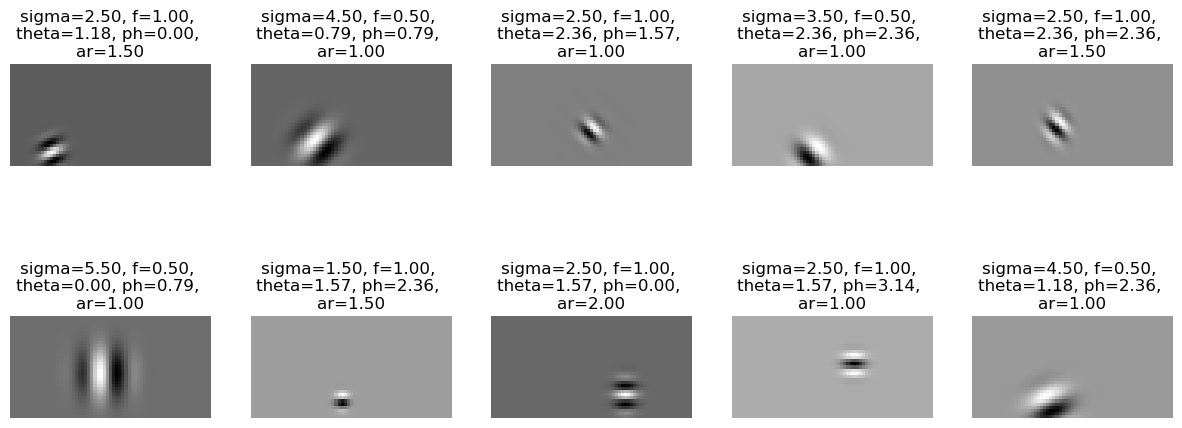

In [ ]:
gabor_filters1.shape
ineurons = np.random.choice(n_neurons, 10, replace=False)
import matplotlib.pyplot as plt 
fig, ax = plt.subplots(2, 5, figsize=(15,6))
for i, axi in enumerate(ax.flat):
    axi.imshow(gabor_filters1[ineurons[i]].cpu().numpy().squeeze(), cmap='gray')
    axi.axis('off')
    axi.set_title(f'sigma={msigma[ineurons[i]].item():.2f}, f={mf[ineurons[i]].item():.2f}, \ntheta={mtheta[ineurons[i]].item():.2f}, ph={mph[ineurons[i]].item():.2f}, \nar={mar[ineurons[i]].item():.2f}')
plt.show()

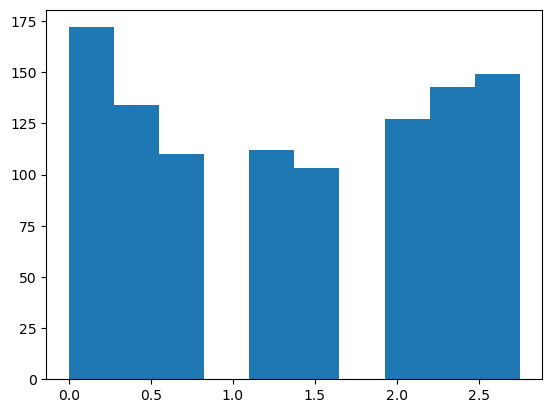

In [ ]:
plt.hist(mtheta.cpu().numpy().flatten())
plt.show()

#complex cells: 26/1050


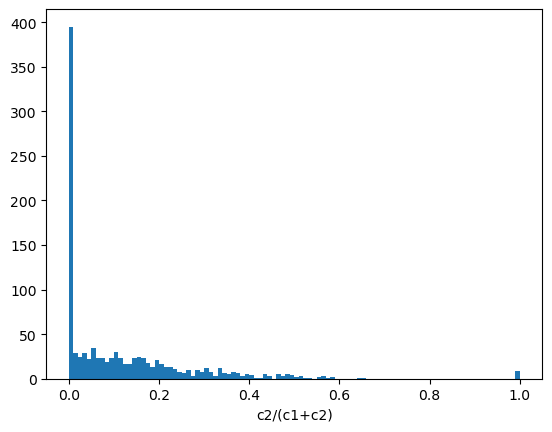

In [ ]:
import matplotlib.pyplot as plt
print(f'#complex cells: {np.sum(cratio > 0.5)}/{n_neurons}')
plt.hist(cratio, bins=100)
plt.xlabel('c2/(c1+c2)')
plt.show()

(-100.0, 100.0)

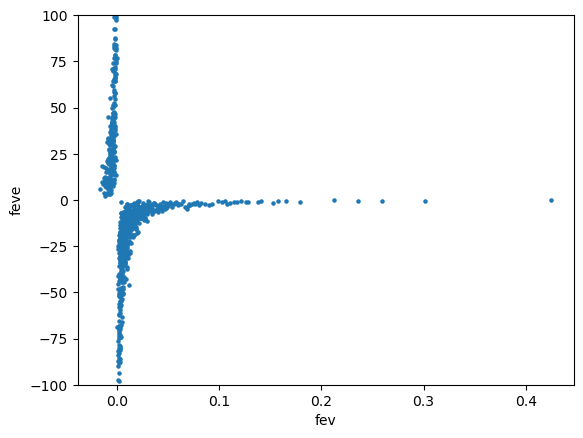

In [ ]:
plt.scatter(fev, feve, s=5)
plt.xlabel('fev')
plt.ylabel('feve')
plt.ylim(-100,100)

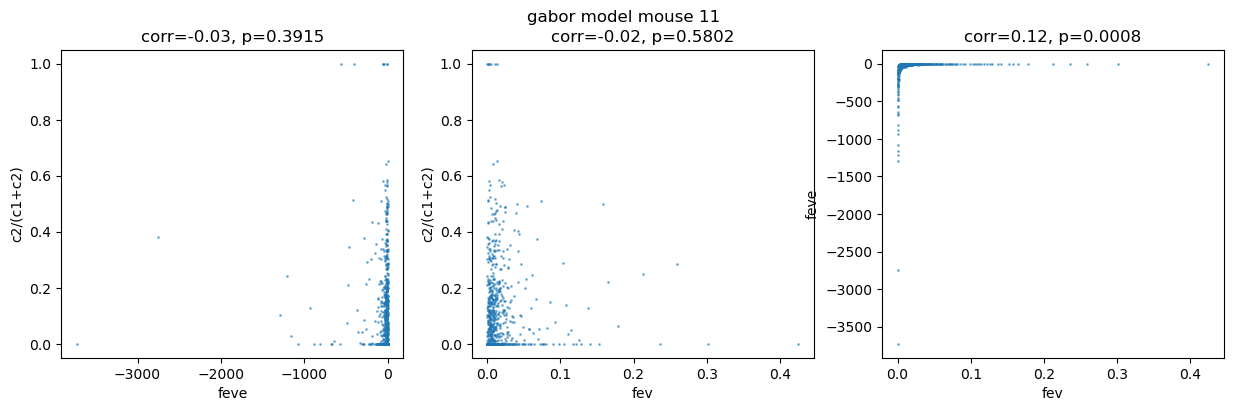

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15,4))
valid_idxes = np.where((fev > 0))[0]
ax[0].scatter(feve[valid_idxes], cratio[valid_idxes], s=1, alpha=0.5)
from scipy.stats import pearsonr
corr, p = pearsonr(feve[valid_idxes], cratio[valid_idxes])
ax[0].set_title(f'corr={corr:.2f}, p={p:.4f}')
ax[0].set_xlabel('feve')
ax[0].set_ylabel('c2/(c1+c2)')
ax[1].scatter(fev[valid_idxes], cratio[valid_idxes], s=1, alpha=0.5)
corr, p = pearsonr(fev[valid_idxes], cratio[valid_idxes])
ax[1].set_title(f'corr={corr:.2f}, p={p:.4f}')
ax[1].set_xlabel('fev')
ax[1].set_ylabel('c2/(c1+c2)')
ax[2].scatter(fev[valid_idxes], feve[valid_idxes], s=1, alpha=0.5)
corr, p = pearsonr(fev[valid_idxes], feve[valid_idxes])
ax[2].set_title(f'corr={corr:.2f}, p={p:.4f}')
ax[2].set_xlabel('fev')
ax[2].set_ylabel('feve')
plt.suptitle(f'gabor model mouse {mouse_id+1}')
plt.show()

torch.Size([3040, 1, 1]) tensor(0.1000) tensor(2.)
torch.Size([3040, 1, 1]) tensor(1.2500) tensor(5.5000)
torch.Size([3040, 1, 1]) tensor(0.) tensor(2.7489)


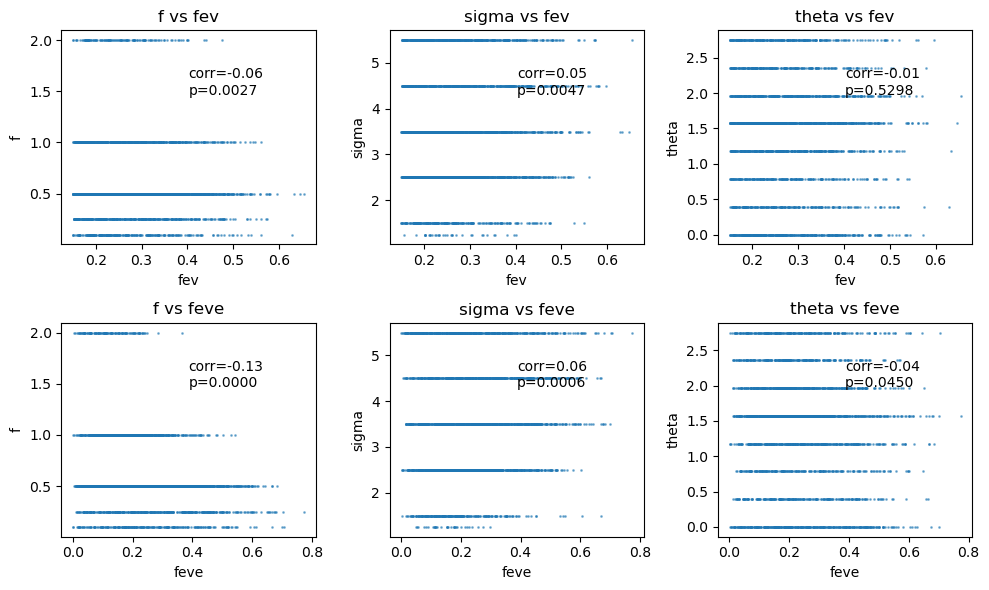

In [ ]:
print(mf.shape, mf.min(), mf.max())
print(msigma.shape, msigma.min(), msigma.max()) # size
print(mtheta.shape, mtheta.min(), mtheta.max()) # orientation
from scipy import stats
fig, ax = plt.subplots(2, 3, figsize=(10,6))
params = [mf.cpu().numpy().squeeze(), msigma.cpu().numpy().squeeze(), mtheta.cpu().numpy().squeeze()]
titles = ['f', 'sigma', 'theta']
# first rwo scatter of params vs fev
for i, axi in enumerate(ax[0]):
    axi.scatter(fev[valid_idxes], params[i][valid_idxes], s=1, alpha=0.5)
    axi.set_ylabel(titles[i])
    axi.set_xlabel('fev')
    axi.set_title(f'{titles[i]} vs fev')
    # pearson correlation and p-value
    corr, p = stats.pearsonr(params[i][valid_idxes], fev[valid_idxes])
    axi.text(0.5, 0.7, f'corr={corr:.2f}\np={p:.4f}', transform=axi.transAxes)

# second row scatter of params vs feve
for i, axi in enumerate(ax[1]):
    axi.scatter(feve[valid_idxes], params[i][valid_idxes], s=1, alpha=0.5)
    axi.set_ylabel(titles[i])
    axi.set_xlabel('feve')
    axi.set_title(f'{titles[i]} vs feve')
    # pearson correlation and p-value
    corr, p = stats.pearsonr(params[i], feve)
    axi.text(0.5, 0.7, f'corr={corr:.2f}\np={p:.4f}', transform=axi.transAxes)
plt.tight_layout()
plt.show()

# fullmodel feve

In [ ]:
# load fullmodel feve
res_dir = '../figures/outputs'
from utils import data
dat = np.load(os.path.join(res_dir, f'fullmodel_{data.mouse_names[mouse_id]}_results.npz'), allow_pickle=True)

fullmodel_feve = dat['fullmodel_feve_all']
nn_all = len(fullmodel_feve)
valid_idxes = dat['valid_idxes']
fullmodel_feve = fullmodel_feve[ineur]

dat = np.load(os.path.join(res_dir, f'minimodel_{data.mouse_names[mouse_id]}_result.npz'), allow_pickle=True)
minimodel_feve = np.inf * np.ones(nn_all)
minimodel_feve[valid_idxes] = dat['feve_all']
minimodel_feve = minimodel_feve[ineur]

print(fullmodel_feve.shape, minimodel_feve.shape)

(3040,) (3040,)


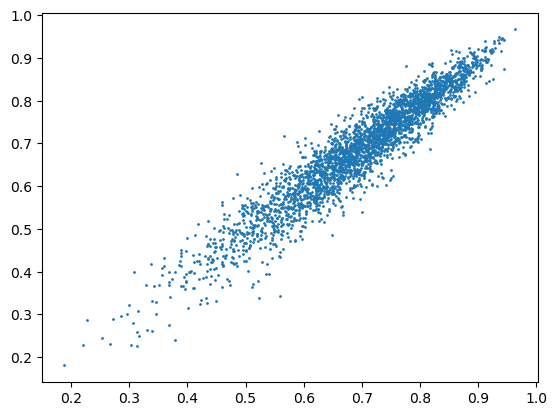

In [ ]:
plt.scatter(fullmodel_feve, minimodel_feve, s=1)

In [ ]:
for k, v in dat.items():
    print(k, v.shape)

feve_depth (4, 4792)
valid_idxes (3040,)
fev (4792,)
feve_width (10, 10, 3040)
feve_nstims (10, 3040)
nstims (10,)
feve_nneurons (10,)
nneurons (10,)
fullmodel_Wx (4792, 65)
fullmodel_Wy (4792, 33)
fullmodel_feve_all (4792,)
fullmodel_conv1_W (16, 25, 25)
LNmodel_feve_all (4792,)


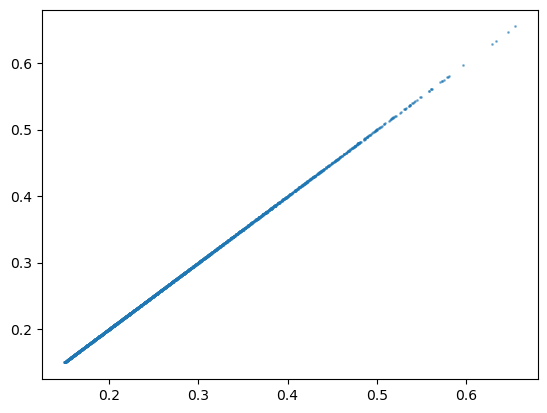

In [ ]:
plt.scatter(fev, dat['fev'][ineur], s=1, alpha=0.5)

fullmodel feve: 0.7015602588653564
gabor feve: 0.24144558608531952


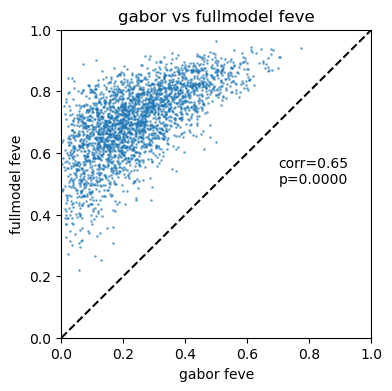

In [ ]:
valid_idxes = np.where(feve > 0.)[0]
fig, ax = plt.subplots(1, 1, figsize=(4,4))
plt.scatter(feve[valid_idxes], fullmodel_feve[valid_idxes], s=1, alpha=0.5)
print(f'fullmodel feve: {fullmodel_feve[valid_idxes].mean()}')
print(f'gabor feve: {feve[valid_idxes].mean()}')
plt.xlabel('gabor feve')
plt.ylabel('fullmodel feve')
plt.title('gabor vs fullmodel feve')
r, p = pearsonr(feve[valid_idxes], fullmodel_feve[valid_idxes])
plt.text(0.7, 0.5, f'corr={r:.2f}\np={p:.4f}', transform=plt.gca().transAxes)
plt.xlim(0,1)
plt.ylim(0,1)
plt.plot([0,1], [0,1], 'k--')
plt.show()

fullmodel feve: 0.6959583759307861
gabor feve: 0.27834585309028625


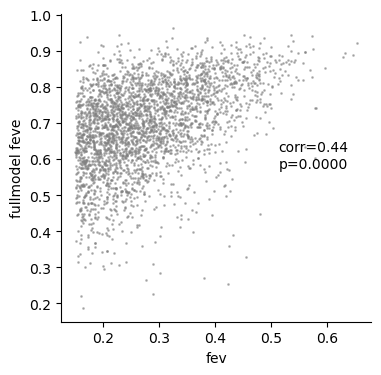

In [ ]:
# valid_idxes = np.where(feve > 0.)[0]
valid_idxes = np.arange(len(feve))
fig, ax = plt.subplots(1, 1, figsize=(4,4))
plt.scatter(fev[valid_idxes], fullmodel_feve[valid_idxes], s=1, alpha=0.5, color='gray')
print(f'fullmodel feve: {fullmodel_feve[valid_idxes].mean()}')
print(f'gabor feve: {fev[valid_idxes].mean()}')
plt.xlabel('fev')
plt.ylabel('fullmodel feve')
# plt.title('fullmodel feve vs fev')
from scipy.stats import pearsonr
r, p = pearsonr(fev[valid_idxes], fullmodel_feve[valid_idxes])
plt.text(0.7, 0.5, f'corr={r:.2f}\np={p:.4f}', transform=plt.gca().transAxes)
# plt.xlim(0,1)
# plt.ylim(0,1)
# plt.plot([0,1], [0,1], 'k--')
# set right spine invisible
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.show()

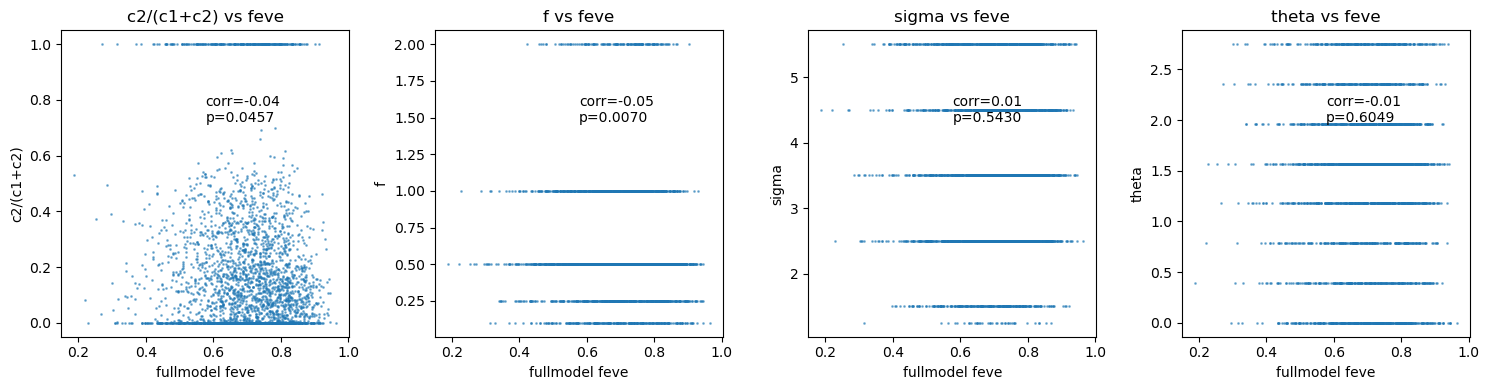

In [ ]:
params = [cratio, mf.cpu().numpy().squeeze(), msigma.cpu().numpy().squeeze(), mtheta.cpu().numpy().squeeze()]
titles = ['c2/(c1+c2)', 'f', 'sigma', 'theta']
from scipy import stats
fig, ax = plt.subplots(1, 4, figsize=(15,4))
for i, axi in enumerate(ax):
    axi.scatter(fullmodel_feve[valid_idxes], params[i][valid_idxes], s=1, alpha=0.5)
    axi.set_ylabel(titles[i])
    axi.set_xlabel('fullmodel feve')
    axi.set_title(f'{titles[i]} vs feve')
    # pearson correlation and p-value
    corr, p = stats.pearsonr(params[i][valid_idxes], fullmodel_feve[valid_idxes])
    axi.text(0.5, 0.7, f'corr={corr:.2f}\np={p:.4f}', transform=axi.transAxes)
plt.tight_layout()
plt.show()

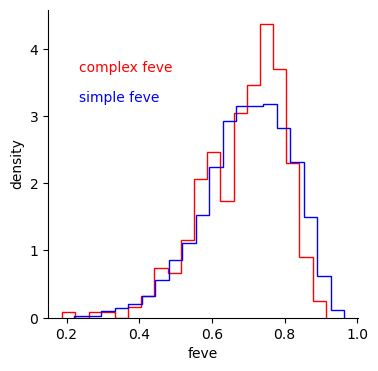

In [ ]:
param = params[0]
icomplex = np.where(param > 0.5)[0]
isimple = np.where(param <= 0.5)[0]

fig, ax = plt.subplots(1, 1, figsize=(4,4))
ax.hist(fullmodel_feve[icomplex], bins=20, alpha=1, label='complex', density=True, color='r', histtype='step')
ax.text(0.1, 0.8, f'complex feve', transform=ax.transAxes, color='r')
ax.hist(fullmodel_feve[isimple], bins=20, alpha=1, label='simple', density=True, color='b', histtype='step')
ax.text(0.1, 0.7, f'simple feve', transform=ax.transAxes, color='b')

ax.set_xlabel('feve')
ax.set_ylabel('density')
# set right spine invisible
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
# plt.legend()
plt.show()


/tmp/ipykernel_523073/958652514.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('viridis', len(val) + 1)


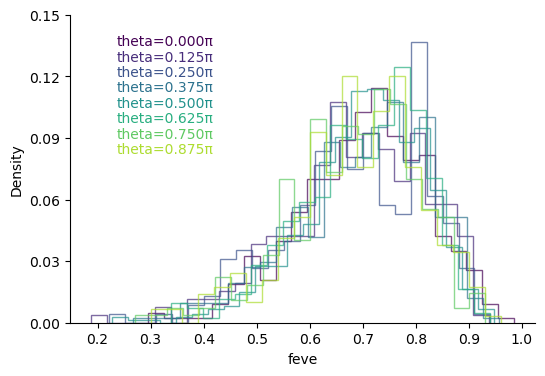

In [ ]:
param = params[1]
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
cmap = plt.cm.get_cmap('viridis', len(val) + 1)

fixed_bar_width = 0.03  # Set a fixed bar width for all distributions

# Iterate over the unique values in the parameter array
for i, v in enumerate(val):
    # Get data for the current parameter value
    data = fullmodel_feve[param == v]
    
    # Calculate bins to ensure consistent bar width
    min_data, max_data = np.min(data), np.max(data)
    bins = np.arange(min_data, max_data + fixed_bar_width, fixed_bar_width)
    
    # Plot histogram with the fixed bar width
    ax.hist(data, bins=bins, alpha=0.7, label=f'{titles[k]}={v:.1f}', 
            density=True, histtype='step', color=cmap(i))
    
    # Add information text
    ax.text(0.1, 0.9 - i * 0.05, 
            f'{titles[k]}={v / np.pi:.3f}π', 
            transform=ax.transAxes, color=cmap(i))
ax.set_yticks(np.arange(5), [f'{i*fixed_bar_width:.2f}' for i in np.arange(5)])
# Customize plot
ax.set_xlabel('feve')
ax.set_ylabel('Density')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

0.313231 0.8670907
0.39807075 0.92132926
0.2274006 0.9638221
0.2856199 0.9446599
0.18827128 0.93400276
0.25300086 0.9429911


/tmp/ipykernel_523073/2416246734.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('viridis', len(val) + 1)


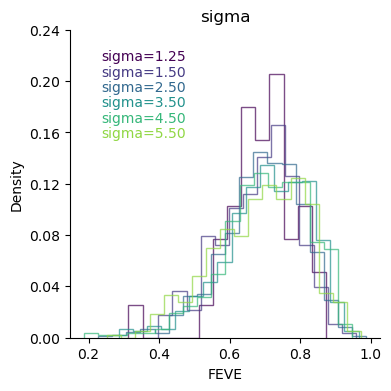

In [ ]:
k = 2
param = params[k]
val, cts = np.unique(param, return_counts=True)
fig, ax = plt.subplots(1, 1, figsize=(4,4))
ax.set_title(f'{titles[k]}')
fixed_bar_width = 0.04  # Set a fixed bar width for all distributions
cmap = plt.cm.get_cmap('viridis', len(val) + 1)
# Iterate over the unique values in the parameter array
for i, v in enumerate(val):
    # Get data for the current parameter value
    data = fullmodel_feve[param == v]
    
    # Calculate bins to ensure consistent bar width
    min_data, max_data = np.min(data), np.max(data)
    print(min_data, max_data)
    bins = np.arange(min_data, max_data + fixed_bar_width, fixed_bar_width)
    
    # Plot histogram with the fixed bar width
    ax.hist(data, bins=bins, alpha=0.7, label=f'{titles[k]}={v:.1f}', 
            density=True, histtype='step', color=cmap(i))
    
    # Add information text
    if k == 3:
        ax.text(0.1, 0.9 - i * 0.05, 
                f'{titles[k]}={v / np.pi:.3f}π', 
                transform=ax.transAxes, color=cmap(i))
    else:
        ax.text(0.1, 0.9 - i * 0.05, 
                f'{titles[k]}={v:.2f}', 
                transform=ax.transAxes, color=cmap(i))
ms = [0,6,7,6]
m = ms[k]
ax.set_yticks(np.arange(m), [f'{i*fixed_bar_width:.2f}' for i in np.arange(m)])
ax.set_xlabel('FEVE')
ax.set_ylabel('Density')
# set right spine invisible
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
# plt.legend()
plt.show()

In [ ]:
len(fev)

3040

In [ ]:
d

NameError: name 'd' is not defined

In [ ]:
d

NameError: name 'd' is not defined

In [ ]:
d

torch.Size([5, 4, 8, 8, 3, 1, 1])

In [ ]:
print(gbest)
print(gmax)

[3770 3285 3723 2942 3428 3551 2271 3725 3713 3812]
[2336 3499 3591 3380 3314 3414 3831 3415 3297 3417]


In [ ]:
rpred = (resp_train1[gmax].T - resp_train1[gmax].mean(axis=-1)) * c[:,0] + (resp_train2[gmax].T - resp_train2[gmax].mean(axis=-1)) * c[:,1] # (n_stim, n_neurons)
vexp = 1 - ((rpred - X_train)**2).sum(axis=0) / (X_train**2).sum(axis=0)
vexp = vexp.cpu().numpy()
print(f'vexp: {vexp.mean()}')

vexp: -0.5077043771743774


In [ ]:
itrain.sum(), itest.sum()

(400, 400)

In [ ]:
plt.scatter(cc[gbest, np.arange(n_neurons)].flatten().cpu().numpy(), vexp.flatten())

NameError: name 'plt' is not defined

In [ ]:
d

In [ ]:
resp_test1 = torch.zeros((n_gabors, itest.sum()), dtype=torch.float32, device=device)
resp_test2 = torch.zeros((n_gabors, itest.sum()), dtype=torch.float32, device=device)
eval_gabors(img[:,:,itest], gabor_filters1, resp_test1, device=device, rectify=False)
eval_gabors(img[:,:,itest], gabor_filters2, resp_test2, device=device, rectify=False)
resp_test2 = torch.sqrt(resp_test1**2 + resp_test2**2) # RMS for complex cell response
resp_test2 = relu(resp_test2) # rectify
resp_test1 = relu(resp_test1) # rectify
c = torch.from_numpy(Amax).to(device)

rpred = ((resp_test1[gmax].T - mu1) * c[:,0] + (resp_test2[gmax].T - mu2) * c[:,1]) # (n_stim, n_neurons)
vexp_test = 1 - ((rpred - X_test)**2).sum(axis=0) / (X_test**2).sum(axis=0)
vexp_test = vexp_test.cpu().numpy()

In [ ]:
from approxineuro.gabor import gabor_filter, eval_gabors
import time
from torch.nn.functional import relu

tic = time.time()

for ycent, xcent in zip(ycents.flatten(), xcents.flatten()):
    # compute responses to gabors
    gabor_filters1 = gabor_filter(ys, xs, ycent, xcent, 1, sigma, f, theta, ph, ar, 
                                    is_torch=True).to(device).unsqueeze(-3)
    eval_gabors(img[:,:,itrain], gabor_filters1, resp_train1, device=device, rectify=False) 
    

    # compute responses to gabors with phase shifted by pi/2
    gabor_filters2 = gabor_filter(ys, xs, ycent, xcent, 1, sigma, f, theta, ph + np.pi/2, ar, 
                                    is_torch=True).to(device).unsqueeze(-3) # phase shifted by pi/2
    eval_gabors(img[:,:,itrain], gabor_filters2, resp_train2, device=device, rectify=False)

    # compute complex cell responses
    resp_train2 = torch.sqrt(resp_train1**2 + resp_train2**2) # RMS for complex cell response
    # rectify
    resp_train2 = relu(resp_train2) # (n_gabors, n_stim)
    resp_train1 = relu(resp_train1) # (n_gabors, n_stim)
    
    mu = resp_train1.mean(axis=-1)
    resp_train1 -= mu.unsqueeze(-1)
    mu = resp_train2.mean(axis=-1)
    resp_train2 -= mu.unsqueeze(-1)

    # print(f'resp_train1: {resp_train1.min()}, {resp_train1.max()}, resp_train2: {resp_train2.min()}, {resp_train2.max()}')

    # compute coefficients for best fit: r = c1*resp1 + c2*resp2 
    # r = X @ c
    # c = (X^T X)^-1 X^T r
    g11 = (resp_train1**2).sum(axis=-1) # variance， size: (n_gabors,)
    g12 = (resp_train1 * resp_train2).sum(axis=-1) # covariance， size: (n_gabors,)
    g22 = (resp_train2**2).sum(axis=-1) # variance， size: (n_gabors,)

    Cov = torch.stack((g11, g12, g12, g22), dim=-1)
    # print(f'Cov: {Cov.shape}')
    Cov = Cov.reshape(-1, 2, 2) # size: (n_gabors, 2, 2)
    Cov += torch.eye(2, device=device).unsqueeze(0) * 1e-6
    # print(f'Cov: {Cov.shape}')
    Covinv = torch.inverse(Cov) # size: (n_gabors, 2, 2)
    # print(f'Covinv: {Covinv.shape}')

    # X^T r
    # resp_train = torch.stack((resp_train1, resp_train2), dim=-1) # size: (n_gabors, n_stim, 2)
    # print(f'resp_train: {resp_train.shape}')
    Xtr1 = (resp_train1 @ X_train) # (n_gabors, n_stim,) @ (n_stim, n_neurons) = (n_gabors, n_neurons) # correlation between gabors and neurons
    Xtr2 = (resp_train2 @ X_train) # (n_gabors, n_stim,) @ (n_stim, n_neurons) = (n_gabors, n_neurons) # correlation between gabors and neurons
    # print(f'Xtr1: {Xtr1.shape}, Xtr2: {Xtr2.shape}')

    Xtr = torch.stack((Xtr1, Xtr2), dim=1) # size: (n_gabors, 2, n_neurons)
    # print(f'Xtr: {Xtr.shape}')
    c = torch.bmm(Covinv, Xtr) # size: (n_gabors, 2, n_neurons)
    # print(f'c: {c.shape}')
    c = relu(c) # rectify
    cc= torch.sum(c * Xtr, dim=1) # size: (n_gabors, n_neurons)

    vbest, gbest = cc.max(axis=0) # return max value and index

    vbest, gbest = vbest.cpu().numpy(), gbest.cpu().numpy()

    c = c[gbest, :, np.arange(n_neurons)] # size: (n_neurons, 2)

    rpred = (resp_train1[gbest].T - resp_train1[gbest].mean(axis=-1)) * c[:,0] + (resp_train2[gbest].T - resp_train2[gbest].mean(axis=-1)) * c[:,1] # (n_stim, n_neurons)
    vexp = 1 - ((rpred - X_train)**2).sum(axis=0) / (X_train**2).sum(axis=0)
    vexp = vexp.cpu().numpy()

    imax = vmax < vexp # update only if new value is greater than old value for each neuron
    vmax[imax] = vexp[imax]
    gmax[imax] = gbest[imax]    
    Amax[imax] = c[imax].cpu().numpy()

    ymax[imax] = ycent.numpy()
    xmax[imax] = xcent.numpy()

    mu1[imax] = resp_train1[gbest[imax]].mean(axis=-1)
    mu2[imax] = resp_train2[gbest[imax]].mean(axis=-1)

    if xcent.numpy() % 5 == 0:
        # test
        resp_test1 = torch.zeros((n_gabors, itest.sum()), dtype=torch.float32, device=device)
        resp_test2 = torch.zeros((n_gabors, itest.sum()), dtype=torch.float32, device=device)
        eval_gabors(img[:,:,itest], gabor_filters1, resp_test1, device=device, rectify=False)
        eval_gabors(img[:,:,itest], gabor_filters2, resp_test2, device=device, rectify=False)
        resp_test2 = torch.sqrt(resp_test1**2 + resp_test2**2) # RMS for complex cell response
        resp_test2 = relu(resp_test2) # rectify
        resp_test1 = relu(resp_test1) # rectify
        c = torch.from_numpy(Amax).to(device)
        
        rpred = ((resp_test1[gmax].T - mu1) * c[:,0] + (resp_test2[gmax].T - mu2) * c[:,1]) # (n_stim, n_neurons)
        vexp = 1 - ((rpred - X_test)**2).sum(axis=0) / (X_test**2).sum(axis=0)
        vexp = vexp.cpu().numpy()

        print(f'y={ycent.numpy():.0f}, x={xcent.numpy():.0f}, vmax={vmax.mean():.3f}, test={vexp.mean():.3f}, time {time.time()-tic:.1f}s')
    

y=0, x=5, vmax=0.143, test=-0.231, time 0.6s
y=0, x=10, vmax=0.143, test=-0.205, time 1.1s
y=0, x=15, vmax=0.143, test=-0.220, time 1.6s
y=0, x=20, vmax=0.143, test=-0.239, time 2.2s
y=0, x=25, vmax=0.143, test=-0.253, time 2.7s
y=0, x=30, vmax=0.143, test=-0.233, time 3.2s
y=0, x=35, vmax=0.143, test=-0.234, time 3.7s
y=0, x=40, vmax=0.143, test=-0.194, time 4.2s
y=0, x=45, vmax=0.143, test=-0.229, time 4.8s
y=0, x=50, vmax=0.143, test=-0.212, time 5.3s
y=0, x=55, vmax=0.143, test=-0.163, time 5.9s
y=0, x=60, vmax=0.143, test=-0.185, time 6.4s
y=1, x=5, vmax=0.143, test=-0.271, time 7.4s
y=1, x=10, vmax=0.143, test=-0.210, time 7.9s
y=1, x=15, vmax=0.143, test=-0.215, time 8.4s
y=1, x=20, vmax=0.143, test=-0.191, time 8.9s
y=1, x=25, vmax=0.143, test=-0.241, time 9.4s
y=1, x=30, vmax=0.143, test=-0.213, time 10.0s
y=1, x=35, vmax=0.143, test=-0.234, time 10.5s
y=1, x=40, vmax=0.143, test=-0.195, time 11.1s
y=1, x=45, vmax=0.143, test=-0.254, time 11.7s
y=1, x=50, vmax=0.143, test=-0.2

KeyboardInterrupt: 

In [ ]:
vbest.shape

(10,)

In [ ]:
resp_train1.shape

torch.Size([3840, 333])

In [ ]:
resp_train1.shape

torch.Size([3840, 333])

In [ ]:
resp_train1.unsqueeze(-1).shape, X_train.unsqueeze(0).shape

(torch.Size([3840, 333, 1]), torch.Size([1, 333, 10]))

In [ ]:
resp_train.unsqueeze(-1).shape, X_train.T.unsqueeze(-1).shape

NameError: name 'resp_train' is not defined

In [ ]:
def fit_gabor_to_resp(X, img, itrain, itest, device = torch.device('cuda')):
    """ fit gabor RFs to neuron responses 
    
    X: n_stim x neurons
    
    img: Ly x Ly x n_stim
    
    
    """
    
    Ly, Lx, n_stim = img.shape
    
    n_neurons = X.shape[1]

    # zscore X
    X = (X - X.mean(axis=0)) / X.std(axis=0)
    X_train = torch.from_numpy(X[itrain].astype('float32'))
    X_test = torch.from_numpy(X[itest])
    
    
    sigma = np.array([0.75, 1.25, 1.5, 2.5, 3.5])
    f = np.array([0.25, 0.5, 1, 2]) #[.01:.02:.13];
    theta = np.arange(0, np.pi, np.pi/8)
    ph = np.arange(0, 2*np.pi, np.pi/4)
    ar = np.array([1, 1.5, 2])

    params = np.meshgrid(sigma, f, theta, ph, ar,
                                          indexing='ij')
    n_gabors = params[0].size
    for i in range(len(params)):
        params[i] = np.expand_dims(params[i], axis=(-2,-1))
        params[i] = torch.from_numpy(params[i].astype('float32'))
    sigma, f, theta, ph, ar = params
    
    ys, xs = np.meshgrid(np.arange(0,Ly), np.arange(0,Lx), indexing='ij')
    ys, xs = torch.from_numpy(ys.astype('float32')), torch.from_numpy(xs.astype('float32'))

    vmax = -np.inf * np.ones((n_neurons,), 'float32')
    Amax = -np.inf * np.ones((n_neurons,), 'float32')
    vmax_test = -np.inf * np.ones((n_neurons,), 'float32')
    imax = np.zeros((n_neurons,), 'int')
    gmax = np.zeros((n_neurons,), 'int')
    ymax = np.zeros((n_neurons,), 'int')
    xmax = np.zeros((n_neurons,), 'int')
    
    resp_train = torch.zeros((n_gabors, itrain.sum()), dtype=torch.float32, device=device)
    X_train = X_train.to(device)

    ycents, xcents = np.meshgrid(np.arange(0,Ly-1,1), np.arange(1,Lx,1), indexing='ij')
    print(ycents.shape)
    ycents, xcents = torch.from_numpy(ycents.astype('float32')), torch.from_numpy(xcents.astype('float32'))
    tic = time.time()
    for ycent, xcent in zip(ycents.flatten(), xcents.flatten()):
        gabor_filters = gabor_filter(ys, xs, ycent, xcent, 1, sigma, f, theta, ph, ar, 
                                     is_torch=True).to(device).unsqueeze(-3)
        eval_gabors(img[:,:,itrain], gabor_filters, resp_train, device=device) # seems we lost some code in eval_gabors()
        mu = resp_train.mean(axis=-1)
        resp_train -= mu.unsqueeze(-1)

        # variance explained of neurons
        cc = resp_train @ X_train
        A = cc / (resp_train**2).sum(axis=-1).unsqueeze(-1)
        varexp = cc**2 / (resp_train**2).sum(axis=-1).unsqueeze(-1)
        vbest, gbest = varexp.max(axis=0)
        vbest, gbest = vbest.cpu().numpy(), gbest.cpu().numpy()
        A = A[gbest, np.arange(0, n_neurons)]
        imax = vmax < vbest
        vmax[imax] = vbest[imax]
        gmax[imax] = gbest[imax]    
        Amax[imax] = A[imax].cpu().numpy()

        ymax[imax] = ycent.numpy()
        xmax[imax] = xcent.numpy()
        if xcent.numpy() % 5 == 0:
            print(f'y={ycent.numpy():.0f}, x={xcent.numpy():.0f}, vmax={vmax.mean():.3f}, time {time.time()-tic:.1f}s')
        
    ym = torch.from_numpy(ymax.astype('float32')).unsqueeze(-1).unsqueeze(-1)
    xm = torch.from_numpy(xmax.astype('float32')).unsqueeze(-1).unsqueeze(-1)
    Am = torch.from_numpy(Amax).unsqueeze(-1).unsqueeze(-1)

    gabor_params = torch.zeros((5, n_neurons, 1, 1))
    for i in range(len(gabor_params)):
        gabor_params[i] = params[i].flatten()[gmax].reshape(n_neurons, 1, 1)
    sigma, f, theta, ph, ar = params
    gabor_filters = gabor_filter(ys, xs, ym, xm, Am, 
                                 *gabor_params, is_torch=True).to(device).unsqueeze(-3)

    batch_size=200
    resp_test = torch.zeros((n_neurons, itest.sum()), dtype=torch.float32)
    for k in np.arange(0,n_neurons, batch_size):
        kend = min(n_neurons, k+batch_size)
        resp_test0 = torch.zeros((kend-k, itest.sum()), dtype=torch.float32, device=device)
        eval_gabors(img[:,:,itest], gabor_filters[k:kend], resp_test0)
        resp_test[k:kend] = resp_test0.cpu()
        resp_train0 = torch.zeros((kend-k, itrain.sum()), dtype=torch.float32, device=device)
        eval_gabors(img[:,:,itrain], gabor_filters[k:kend], resp_train0)
        mu = resp_train0.mean(axis=-1).cpu()
        resp_test[k:kend] -= mu.unsqueeze(-1)

    vtest = 1 - ((resp_test.T - X_test)**2).sum(axis=0) / ((X_test - X_test.mean(axis=0))**2).sum(axis=0)
    print(f'varexp_test = {vtest.mean():.3f}')
    gabor_filters = gabor_filters.cpu().numpy().squeeze()
    gabor_fits_torch = (ym, xm, Am, *gabor_params)
    gabor_fits = []
    for g in gabor_fits_torch:
        gabor_fits.append(g.squeeze().numpy())
    return gabor_filters, gabor_fits, resp_test.T.numpy(), vtest
